[SpekPy] ctor = Spek(kvp=..., th=..., targ=...)
[SpekPy] filter: Air 100.0 mm  via s.filter(mat, thick)
[SpekPy] filter: Gd 0.0 mm  via s.filter(mat, thick)
[SpekPy] spectrum via s.get_spectrum() -> (E, Y)


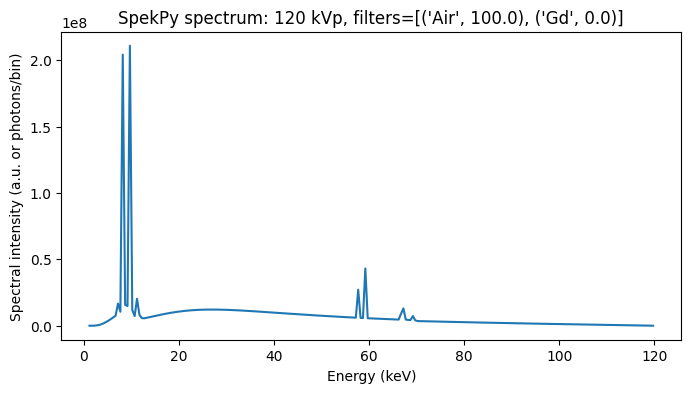

E range: 1.25 -> 119.75 keV
spec min/max: 0.000588161988123381 210827351.78378198


In [25]:
# =========================
# SpekPy: generate spectrum
# =========================
# 在 notebook 里先装包（如果你已装可跳过）
# !pip install spekpy matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import spekpy as sp

def spekpy_spectrum(kvp,
                    filters=None,
                    th=12,          # anode angle (deg) 常见 12
                    targ="W",       # tungsten
                    dk=0.5,         # energy bin width (keV)（不同版本不一定支持）
                    return_keV=True):
    """
    输入：
      kvp: 管电压 (kVp)
      filters: [("Al", 2.0), ("Cu", 0.2)]  # 厚度单位：mm（SpekPy通常用 mm）
      th: 阳极角（度）
      targ: 靶材（W）
    输出：
      E_keV: 能量轴
      sp: 光子谱（单位取决于 SpekPy 版本/设置，通常是相对强度或每能量间隔的光子数）
    """
    if filters is None:
        filters = []


    # --- 1) 构造 Spek 对象（不同版本参数名不一样） ---
    Spek = getattr(sp, "Spek", None)
    if Spek is None:
        raise RuntimeError("没找到 spekpy.Spek，请确认 spekpy 安装是否正确。")

    # 兼容两种常见写法：Spek(kvp=..., th=..., targ=...) 或 Spek(kvp, th, targ)
    try:
        s = Spek(kvp=kvp, th=th, targ=targ)
        ctor_style = "Spek(kvp=..., th=..., targ=...)"
    except TypeError:
        s = Spek(kvp, th, targ)
        ctor_style = "Spek(kvp, th, targ)"
    print("[SpekPy] ctor =", ctor_style)

    # --- 2) 加滤片（常见函数名：filter / add_filter） ---
    for (mat, thick_mm) in filters:
        if hasattr(s, "filter"):
            # 有的版本是 s.filter("Al", 2.0)
            try:
                s.filter(mat, thick_mm)
                print(f"[SpekPy] filter: {mat} {thick_mm} mm  via s.filter(mat, thick)")
                continue
            except TypeError:
                pass

        if hasattr(s, "add_filter"):
            # 有的版本是 s.add_filter("Al", 2.0)
            s.add_filter(mat, thick_mm)
            print(f"[SpekPy] filter: {mat} {thick_mm} mm  via s.add_filter(mat, thick)")
            continue

        raise RuntimeError("这个 spekpy 版本里没找到 filter/add_filter 方法。")

    # --- 3) 取谱（常见：get_spectrum / spectrum / get_spectrum( ... )） ---
    E = None
    Y = None

    if hasattr(s, "get_spectrum"):
        try:
            out = s.get_spectrum()  # 有的版本返回 (E, Y)
            if isinstance(out, (tuple, list)) and len(out) >= 2:
                E, Y = out[0], out[1]
                print("[SpekPy] spectrum via s.get_spectrum() -> (E, Y)")
        except TypeError:
            pass

    if (E is None or Y is None) and hasattr(s, "spectrum"):
        out = s.spectrum
        # 有的版本 spectrum 是 dict 或对象
        if isinstance(out, (tuple, list)) and len(out) >= 2:
            E, Y = out[0], out[1]
            print("[SpekPy] spectrum via s.spectrum -> (E, Y)")
        elif isinstance(out, dict) and ("E" in out and ("I" in out or "Y" in out)):
            E = out["E"]
            Y = out.get("I", out.get("Y"))
            print("[SpekPy] spectrum via s.spectrum dict")

    if E is None or Y is None:
        # 最后兜底：尝试常见属性名
        for e_key in ["E", "energy", "energies"]:
            for y_key in ["I", "fluence", "spectrum", "intensity", "Y"]:
                if hasattr(s, e_key) and hasattr(s, y_key):
                    E = getattr(s, e_key)
                    Y = getattr(s, y_key)
                    print(f"[SpekPy] spectrum via attrs: {e_key}, {y_key}")
                    break
            if E is not None and Y is not None:
                break

    if E is None or Y is None:
        raise RuntimeError("没能从这个 spekpy 版本里取到能量轴/谱。把 dir(s) 的输出贴我一下我给你精确适配。")

    E = np.asarray(E, dtype=float)
    Y = np.asarray(Y, dtype=float)

    # 有些版本 E 可能是 eV
    if return_keV and (E.max() > 1000):  # 粗略判断
        E = E / 1000.0

    return E, Y


# ==========
# 你只改这里
# ==========
kvp = 120
filters = [("Air", 100.0), ("Gd", 0.000) ]   # 例：0.3 mm Gd；也可以 [("Al", 2.0), ("Cu", 0.2)]
th = 12                   # 阳极角（度）
targ = "W"                # 靶材（W）  (targ = 'Cr', 'Cu', 'Mo', 'Rh', 'Ag', 'W' or 'Au')

E_keV, spec = spekpy_spectrum(kvp, filters=filters, th=th, targ=targ)

# 画图
plt.figure(figsize=(8,4))
plt.plot(E_keV, spec)
plt.xlabel("Energy (keV)")
plt.ylabel("Spectral intensity (a.u. or photons/bin)")
plt.title(f"SpekPy spectrum: {kvp} kVp, filters={filters}")
# plt.grid(True)
plt.show()

print("E range:", E_keV.min(), "->", E_keV.max(), "keV")
print("spec min/max:", float(spec.min()), float(spec.max()))
